# Agrupando colores

Vamos a crear imagenes con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#### 2. Lee una imagen
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una imagen pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

In [34]:
image = plt.imread(r"C:\Users\NaiaJon\Pictures\20\2019.JPG")
image.shape

(644, 1320, 3)

Muestra la imagen para ver que se ha cargado bien

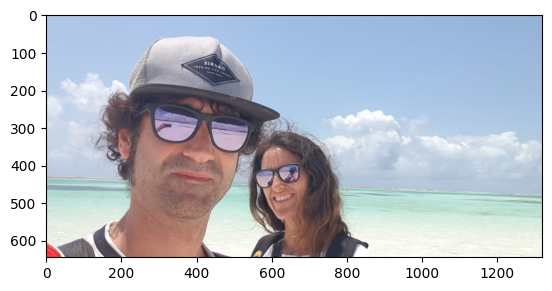

In [35]:
plt.imshow(image)

#### 3. Modifica la estructura de la imagen
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra imagen de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [36]:
# Sacamos cada dimension y multiplicamos

alto, ancho, color = image.shape

img_reshaped= image.reshape(alto*ancho,color)

#### 4. K-means
Haz un k-means con la imagen de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu imagen de salida

In [37]:
X = img_reshaped
X
# En X tenemos los tres canales de color

array([[175, 198, 232],
       [175, 198, 232],
       [175, 198, 232],
       ...,
       [245, 247, 236],
       [244, 246, 235],
       [243, 245, 234]], shape=(850080, 3), dtype=uint8)

In [38]:
# viendo la imagen las voy a agrupar en 8 colores
kmeans8 = KMeans (n_clusters=8, n_init=10, random_state=42)
# Entreno y que me de las predicciones
labels = kmeans8.fit_predict (X)

In [39]:
# Tengo para cada pixel de la imagen la categoría que le ha asignado
labels

array([1, 1, 1, ..., 3, 3, 3], shape=(850080,), dtype=int32)

#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizlos para crear una nueva imagen (recuerda que las imagenes simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [40]:
# Centroides (k colores)
centroides = kmeans8.cluster_centers_
centroides
# Aquí me da los 8 centroides (colores) que ha distinguido

array([[ 70.77545509,  63.15402736,  72.56315289],
       [179.3895374 , 200.72276833, 224.97331791],
       [172.79135249, 124.56424036, 113.13289383],
       [237.27688073, 242.35351699, 237.2973828 ],
       [162.08557115, 161.31182183, 171.52764917],
       [126.44140423,  99.34947267,  99.8885611 ],
       [202.88657863, 221.31242897, 225.11341337],
       [160.42499304, 189.56345439, 224.92800833]])

In [41]:
# Sustituir cada pixel por su centroide
img_compressed = centroides[labels]

#### 6. Modifica la estructura de la imagen
Para trabajar con el k-means requeriamos que la imagen original fuese un solo vector, ahora como queremos volver a tener la imagen para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la imagen original te será más facil hacer este paso)

In [42]:
imagen_reconstruida = img_compressed.reshape(alto, ancho, 3)

#### 7. Muestra y guarda en tu ordenador la imagen resultante

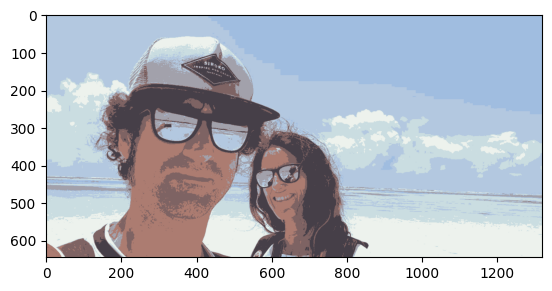

In [43]:

# los centros están con muchos decimales y me daba error al leerlos como RGB. Convierto a enteros
imagen_reconstruida = imagen_reconstruida.astype('uint8')
plt.imshow (imagen_reconstruida)

In [ ]:
# guardamos
from PIL import Image
Image.fromarray(imagen_reconstruida).save("imagen_comprimida.png")


#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una imagen, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla

In [ ]:
# Es el proceso de arriba paso a paso

def comprime_imagen (url_imagen, num_colores, accion):
    #Leemos la imagen
    imagen = plt.imread (url_imagen)

    #Comprimimos y hacemos kmeans al número de colores indicado
    alto, ancho, color = imagen.shape
    X = imagen.reshape(alto*ancho,color)
    kmeans = KMeans (n_clusters=num_colores, n_init=10)
    labels = kmeans.fit_predict(X)
    centroides = kmeans.cluster_centers_

    #Con los parámetros de la compresión sustituimos los colores
    nueva_imagen = centroides[labels]

    # Volvemos a las dimensiones originales de la imagen
    imagen_final = nueva_imagen.reshape(alto, ancho, 3)
    imagen_final = imagen_final.astype('uint8')

    # Guardar o mostrar según accion
    if accion == 'G': # guardar
        from PIL import Image
        Image.fromarray(imagen_final).save("nueva_comprimida.png")
    elif accion == 'M': # mostrar 
        plt.imshow (imagen_final)
    else:
        print ('La acción elegida no es correcta: G: guardar o M: mostrar')



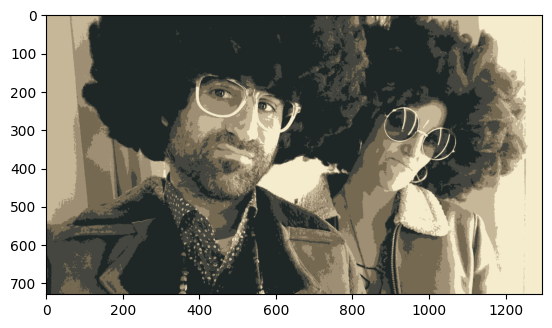

In [31]:
# hacemos la prueba
comprime_imagen (r"C:\Users\NaiaJon\Pictures\20\2017.JPG", 6, 'M')

In [32]:
comprime_imagen (r"C:\Users\NaiaJon\Pictures\20\2017.JPG", 6, 'G')